# Zomato Bangalore — Restaurant & Ratings Analysis
### Data cleaning, exploratory analysis, and platform recommendations

**Prepared for:** Alfido Tech style analytics platform
**Dataset:** `zomato.csv` — Zomato restaurant listings for Bangalore

This notebook covers:
1. Data loading & quality assessment
2. Data cleaning (structural repair, missing values, type/currency conversion)
3. Feature engineering
4. Exploratory analysis — cuisines, locations, price vs rating, service features
5. Visualizations — bar charts, scatter, heatmaps, word clouds
6. Key findings & 5 recommendations for Alfido Tech


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option('display.max_columns', None)

df_raw = pd.read_csv('zomato.csv')
print("Raw shape:", df_raw.shape)
df_raw.head(3)

Raw shape: (56252, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet


## 1. Data Quality Assessment

The raw file has a structural problem: for a large share of rows the fields are **shifted**, so
columns like `rate`, `location`, or `listed_in(type)` contain restaurant-review text instead of the
values they're supposed to hold (this happened upstream, before the CSV reached us — not a parsing
error on our side, since every row does have the correct number of 13 fields).

We detect this by checking whether each "structural" column matches its expected pattern
(e.g. `rate` should look like `4.1/5`, `NEW`, `-`, or be blank; `online_order`/`book_table` should be
`Yes`/`No`; `listed_in(type)` should be one of a fixed set of categories). Rows that fail these checks
are corrupted beyond reliable repair and are dropped rather than guessed at.

In [2]:
good_rate   = df_raw['rate'].astype(str).str.match(r'^\d\.\d/5$|^NEW$|^-$', na=False) | df_raw['rate'].isna()
good_online = df_raw['online_order'].isin(['Yes', 'No'])
good_book   = df_raw['book_table'].isin(['Yes', 'No'])
good_votes  = df_raw['votes'].astype(str).str.match(r'^\d+$', na=False)
good_listed = df_raw['listed_in(type)'].isin(
    ['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out', 'Drinks & nightlife', 'Pubs and bars']
)

valid = good_rate & good_online & good_book & good_votes & good_listed
print(f"Structurally valid rows: {valid.sum():,} / {len(df_raw):,}  ({valid.mean():.1%})")
print(f"Corrupted / shifted rows dropped: {(~valid).sum():,}")

df = df_raw.loc[valid].copy()

Structurally valid rows: 29,549 / 56,252  (52.5%)
Corrupted / shifted rows dropped: 26,703


## 2. Cleaning & Type Conversion

* `rate` → numeric `rating` (drop the `/5`, treat `NEW`/`-` as missing)
* `votes` → integer
* `approx_cost(for two people)` → numeric `cost_for_two` (strip thousands-separator commas; values are already in ₹, so no currency conversion is needed)
* Strip whitespace from text fields and standardise missing markers
* Drop exact duplicate restaurant listings (same name + address, which occur because a restaurant can appear once per service category)

In [3]:
df['rate'] = df['rate'].replace({'NEW': np.nan, '-': np.nan})
df['rating'] = df['rate'].str.replace('/5', '', regex=False).astype(float)
df['votes'] = df['votes'].astype(int)

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '', regex=False)
df['cost_for_two'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce')

for col in ['name', 'location', 'rest_type', 'cuisines', 'dish_liked']:
    df[col] = df[col].astype(str).str.strip()
    df.loc[df[col].isin(['nan', 'None', '']), col] = np.nan

df = df.drop_duplicates(subset=['name', 'address'])
print("Clean shape:", df.shape)
df[['rating', 'votes', 'cost_for_two', 'location', 'rest_type', 'cuisines']].isna().sum()

Clean shape: (10296, 15)


rating          3189
votes              0
cost_for_two      47
location           9
rest_type         58
cuisines          19
dtype: int64

## 3. Feature Engineering

* `primary_cuisine` — first cuisine listed (used as the restaurant's main cuisine)
* `primary_rest_type` — first restaurant-type tag
* `n_cuisines` — how many cuisines a restaurant offers
* `cost_bucket` — price bracket for cost-vs-rating analysis

In [4]:
df['primary_cuisine'] = df['cuisines'].str.split(',').str[0].str.strip()
df['primary_rest_type'] = df['rest_type'].str.split(',').str[0].str.strip()
df['n_cuisines'] = df['cuisines'].str.split(',').apply(lambda x: len(x) if isinstance(x, list) else 0)
df['cost_bucket'] = pd.cut(
    df['cost_for_two'],
    bins=[0, 300, 600, 1000, 1500, 2500, 100000],
    labels=['<300', '300-600', '600-1000', '1000-1500', '1500-2500', '2500+']
)

df.to_csv('zomato_clean.csv', index=False)
df.describe(include='all').T.head(15)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
address,10296,9518,Delivery Only,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,10296,7528,Cafe Coffee Day,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
online_order,10296,2,Yes,5476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
book_table,10296,2,No,9598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rate,7107,30,3.7/5,693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
votes,10296.0,NaN,NaN,NaN,155.132382,527.267162,0.0,0.0,19.0,104.0,16345.0
phone,10071,8981,080 43334333,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,10287,92,Electronic City,717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rest_type,10238,88,Quick Bites,4184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dish_liked,3503,3284,Biryani,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Analysis

### 4.1 Overall rating distribution

Restaurants analysed: 10296
Average rating: 3.62
Median cost for two: ₹ 400.0


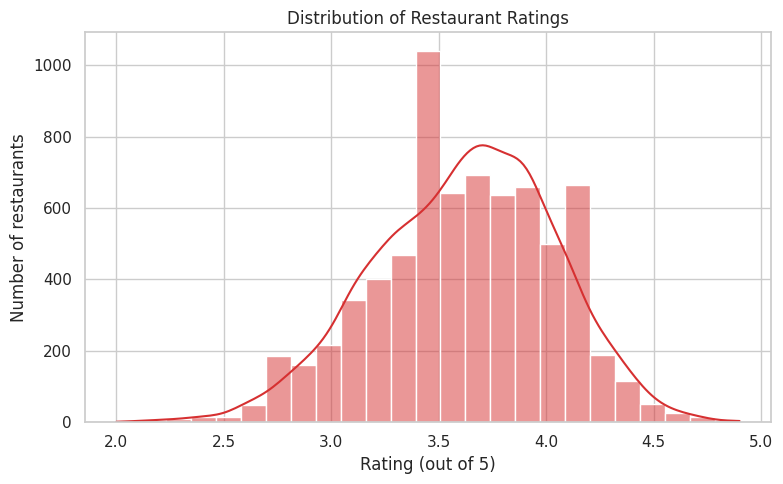

In [5]:
print("Restaurants analysed:", len(df))
print("Average rating:", round(df['rating'].mean(), 2))
print("Median cost for two: ₹", df['cost_for_two'].median())

plt.figure(figsize=(8,5))
sns.histplot(df['rating'].dropna(), bins=25, color="#d63031", kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating (out of 5)'); plt.ylabel('Number of restaurants')
plt.tight_layout(); plt.show()

### 4.2 Location hotspots — where are most restaurants concentrated?

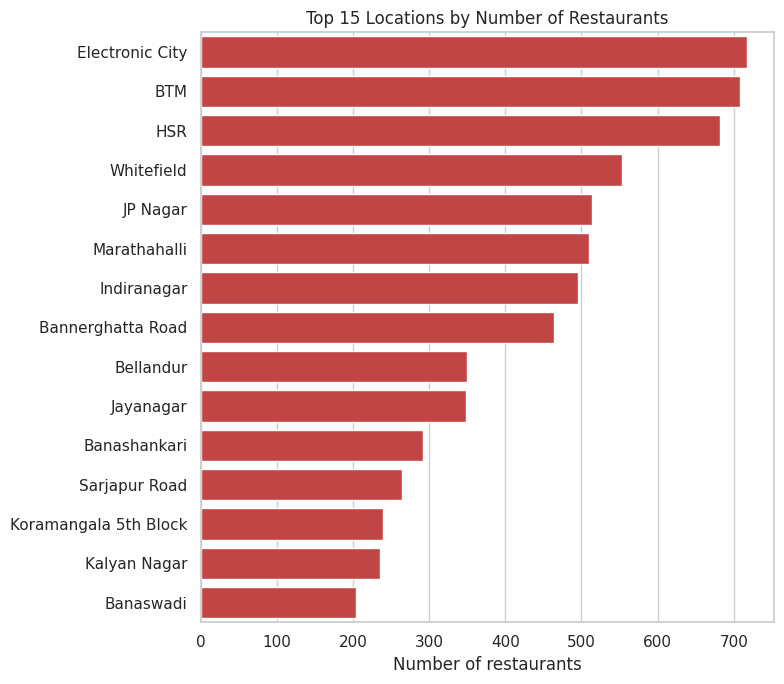

location
Electronic City          717
BTM                      708
HSR                      682
Whitefield               553
JP Nagar                 514
Marathahalli             510
Indiranagar              496
Bannerghatta Road        464
Bellandur                350
Jayanagar                348
Banashankari             292
Sarjapur Road            264
Koramangala 5th Block    240
Kalyan Nagar             236
Banaswadi                204
Name: count, dtype: int64

In [6]:
top_loc = df['location'].value_counts().head(15)
plt.figure(figsize=(8,7))
sns.barplot(x=top_loc.values, y=top_loc.index, color="#d63031")
plt.title('Top 15 Locations by Number of Restaurants')
plt.xlabel('Number of restaurants'); plt.ylabel('')
plt.tight_layout(); plt.show()

top_loc

### 4.3 Which locations rate best (min. 30 restaurants)?

In [7]:
loc_stats = (df.groupby('location')
               .agg(count=('rating', 'size'), avg_rating=('rating', 'mean'), avg_cost=('cost_for_two', 'mean'))
               .query('count >= 30')
               .sort_values('avg_rating', ascending=False))
loc_stats.head(15)

,count,avg_rating,avg_cost
location,,,
Lavelle Road,51,4.038298,1250.980392
St. Marks Road,32,3.932258,734.375000
Church Street,51,3.925000,735.294118
Koramangala 5th Block,240,3.876415,550.000000
Residency Road,74,3.875000,987.837838
Koramangala 4th Block,111,3.837037,572.522523
Richmond Road,89,3.832787,718.539326
MG Road,83,3.820000,1095.180723
Jayanagar,348,3.772028,439.337176


### 4.4 Cuisine popularity and quality

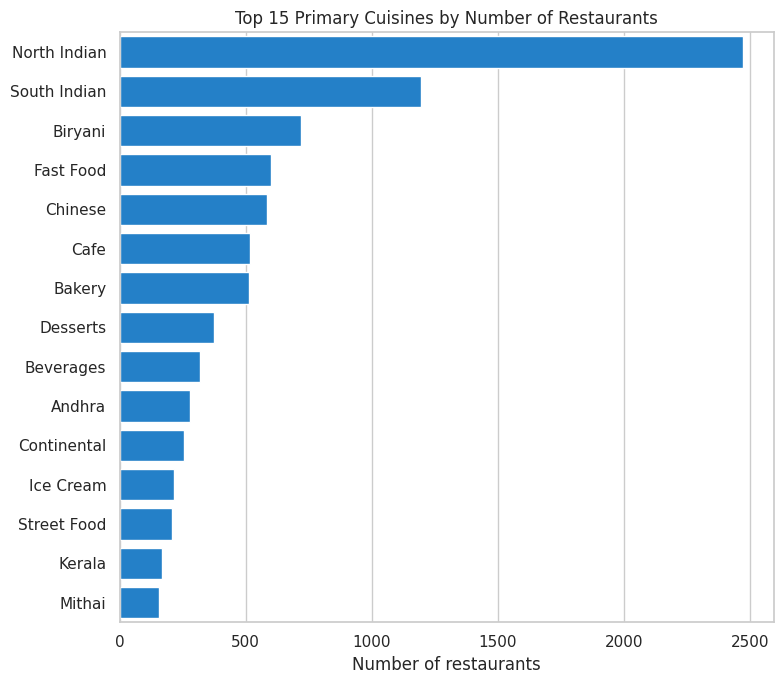

In [8]:
top_cuis = df['primary_cuisine'].value_counts().head(15)
plt.figure(figsize=(8,7))
sns.barplot(x=top_cuis.values, y=top_cuis.index, color="#0984e3")
plt.title('Top 15 Primary Cuisines by Number of Restaurants')
plt.xlabel('Number of restaurants'); plt.ylabel('')
plt.tight_layout(); plt.show()

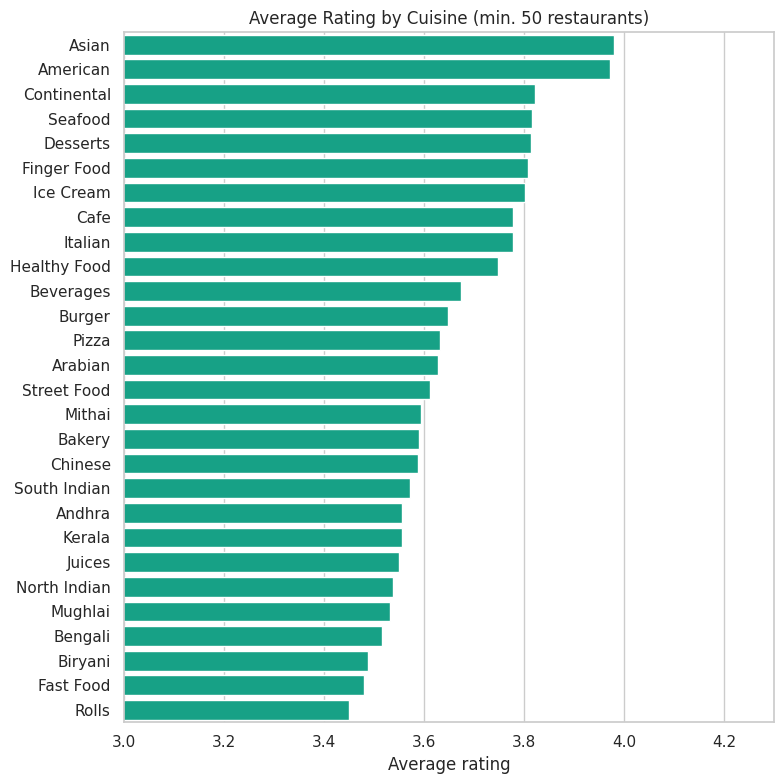

,count,avg_rating
primary_cuisine,,
Asian,51,3.980000
American,71,3.972549
Continental,257,3.820976
Seafood,61,3.815686
Desserts,374,3.814829
Finger Food,72,3.808475
Ice Cream,217,3.801183
Cafe,516,3.778795
Italian,104,3.778409


In [9]:
cuis_stats = (df.groupby('primary_cuisine')
                .agg(count=('rating', 'size'), avg_rating=('rating', 'mean'))
                .query('count >= 50')
                .sort_values('avg_rating', ascending=False))

plt.figure(figsize=(8,8))
sns.barplot(x=cuis_stats['avg_rating'], y=cuis_stats.index, color="#00b894")
plt.title('Average Rating by Cuisine (min. 50 restaurants)')
plt.xlabel('Average rating'); plt.ylabel(''); plt.xlim(3, 4.3)
plt.tight_layout(); plt.show()

cuis_stats

### 4.5 Price vs rating

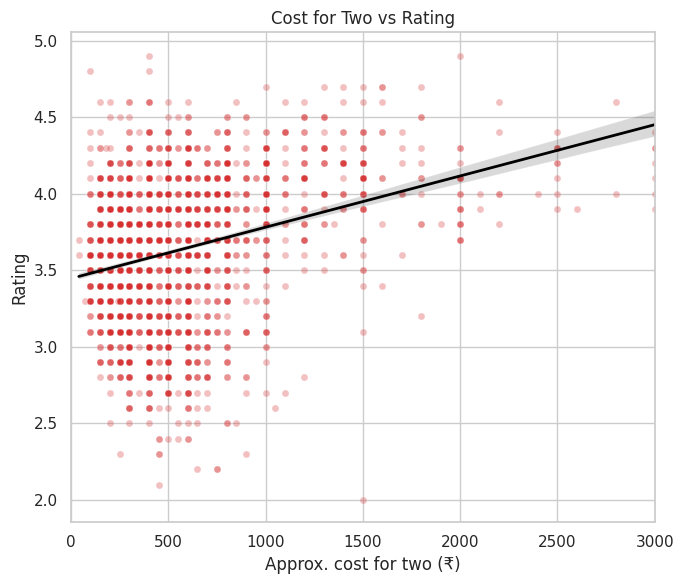

Correlation matrix:


,cost_for_two,rating,votes
cost_for_two,1.000000,0.301625,0.329214
rating,0.301625,1.000000,0.368894
votes,0.329214,0.368894,1.000000


In [10]:
sample = df.dropna(subset=['cost_for_two', 'rating']).sample(min(3000, len(df)), random_state=1)

plt.figure(figsize=(7,6))
sns.scatterplot(data=sample, x='cost_for_two', y='rating', alpha=0.3, color="#d63031", s=25)
sns.regplot(data=sample, x='cost_for_two', y='rating', scatter=False, color='black', line_kws={'linewidth':2})
plt.title('Cost for Two vs Rating'); plt.xlabel('Approx. cost for two (₹)'); plt.ylabel('Rating')
plt.xlim(0, 3000)
plt.tight_layout(); plt.show()

print("Correlation matrix:")
df[['cost_for_two', 'rating', 'votes']].corr()

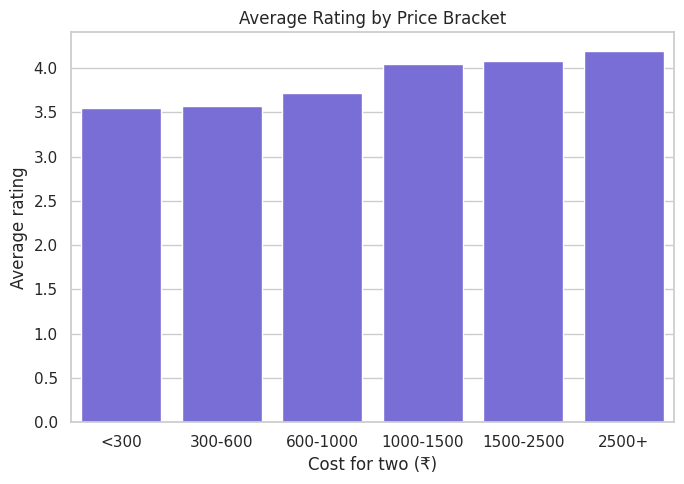

cost_bucket
<300         3.547774
300-600      3.568426
600-1000     3.717705
1000-1500    4.044214
1500-2500    4.083453
2500+        4.192308
Name: rating, dtype: float64

In [11]:
cb = df.groupby('cost_bucket', observed=True)['rating'].mean()
plt.figure(figsize=(7,5))
sns.barplot(x=cb.index, y=cb.values, color="#6c5ce7")
plt.title('Average Rating by Price Bracket')
plt.xlabel('Cost for two (₹)'); plt.ylabel('Average rating')
plt.tight_layout(); plt.show()
cb

### 4.6 Do online ordering and table booking correlate with rating?

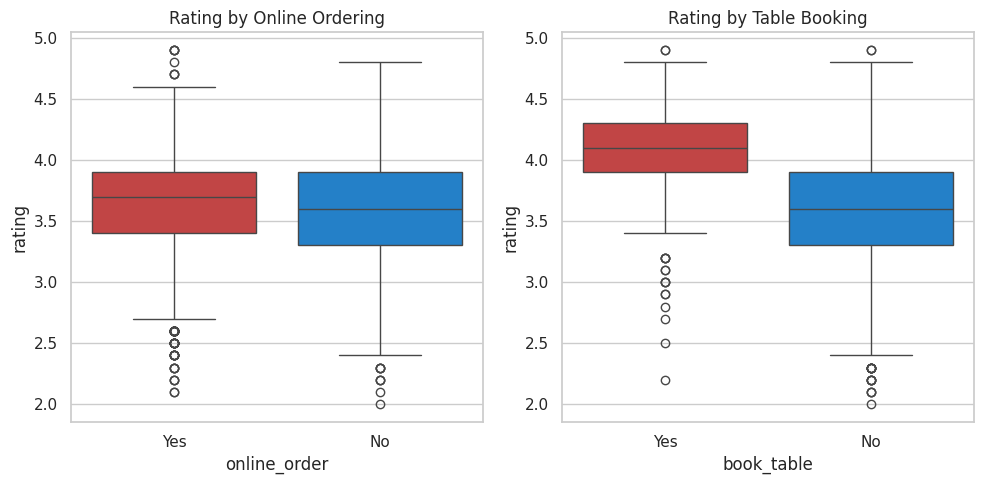

                  mean  count
online_order                 
No            3.577892   2533
Yes           3.644338   4574

                mean  count
book_table                 
No          3.573411   6435
Yes         4.073065    672


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.boxplot(data=df, x='online_order', y='rating', hue='online_order', ax=axes[0], legend=False, palette=["#d63031","#0984e3"])
axes[0].set_title('Rating by Online Ordering')
sns.boxplot(data=df, x='book_table', y='rating', hue='book_table', ax=axes[1], legend=False, palette=["#d63031","#0984e3"])
axes[1].set_title('Rating by Table Booking')
plt.tight_layout(); plt.show()

print(df.groupby('online_order')['rating'].agg(['mean','count']))
print()
print(df.groupby('book_table')['rating'].agg(['mean','count']))

### 4.7 Restaurant type performance

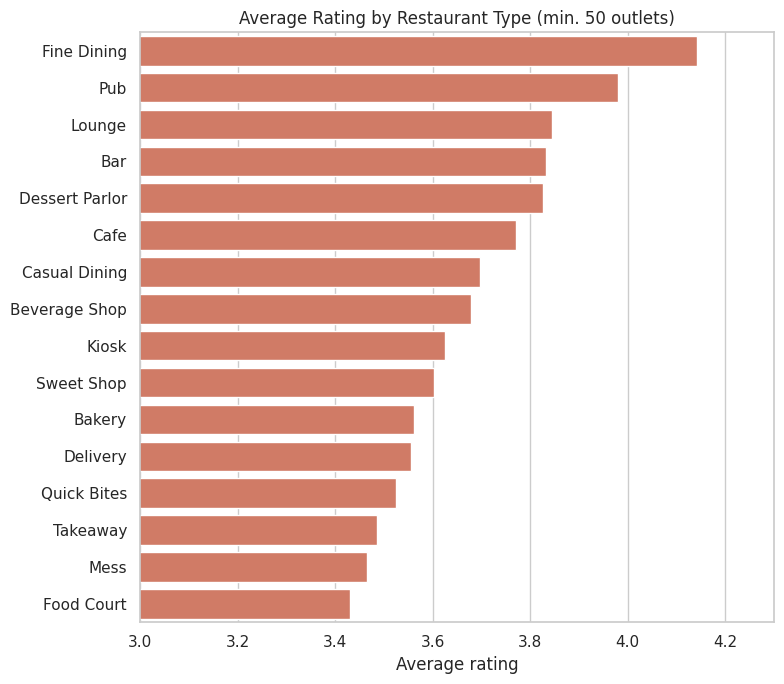

In [13]:
rt_stats = (df.groupby('primary_rest_type')
              .agg(count=('rating', 'size'), avg_rating=('rating', 'mean'))
              .query('count >= 50')
              .sort_values('avg_rating', ascending=False))

plt.figure(figsize=(8,7))
sns.barplot(x=rt_stats['avg_rating'], y=rt_stats.index, color="#e17055")
plt.title('Average Rating by Restaurant Type (min. 50 outlets)')
plt.xlabel('Average rating'); plt.ylabel(''); plt.xlim(3, 4.3)
plt.tight_layout(); plt.show()

### 4.8 Heatmap — location × cuisine average rating

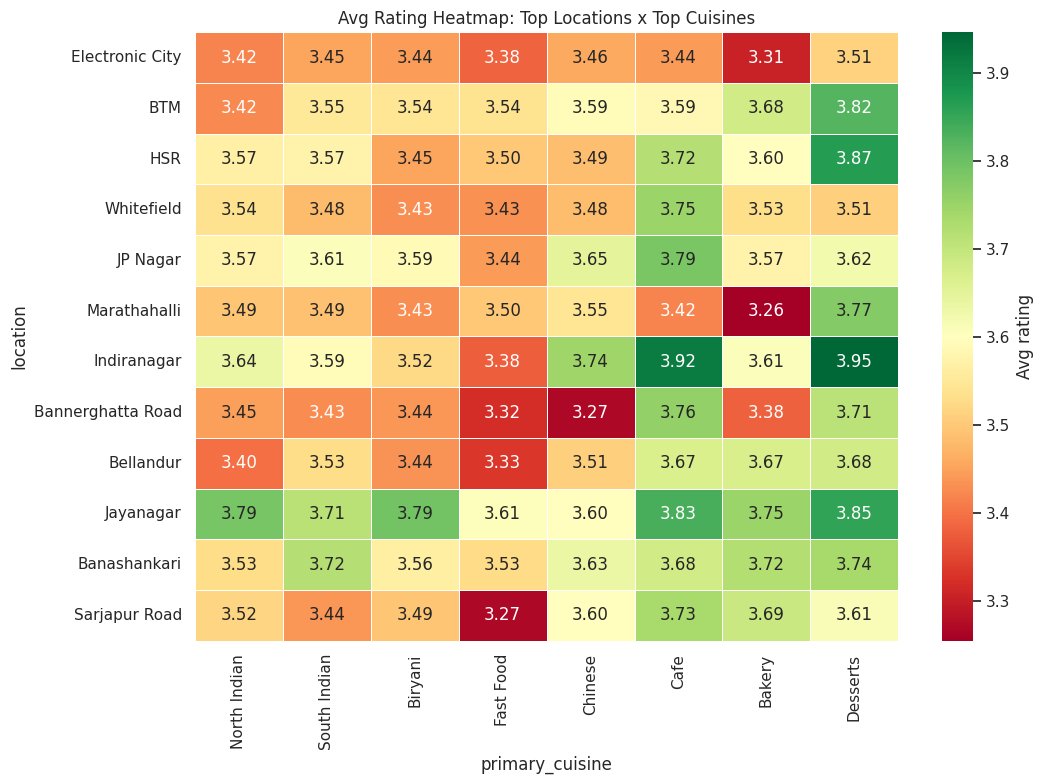

In [14]:
top12_loc = df['location'].value_counts().head(12).index
top8_cuis = df['primary_cuisine'].value_counts().head(8).index
sub = df[df['location'].isin(top12_loc) & df['primary_cuisine'].isin(top8_cuis)]
pivot = sub.pivot_table(index='location', columns='primary_cuisine', values='rating', aggfunc='mean')
pivot = pivot.loc[top12_loc, top8_cuis]

plt.figure(figsize=(11,8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', linewidths=0.5, cbar_kws={'label': 'Avg rating'})
plt.title('Avg Rating Heatmap: Top Locations x Top Cuisines')
plt.tight_layout(); plt.show()

### 4.9 Correlation heatmap

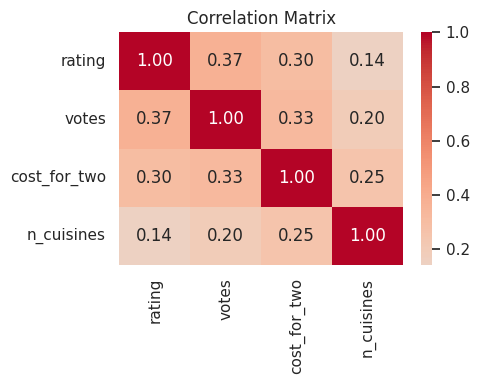

In [15]:
plt.figure(figsize=(5,4))
corr = df[['rating', 'votes', 'cost_for_two', 'n_cuisines']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout(); plt.show()

### 4.10 Word clouds — popular dishes & cuisines

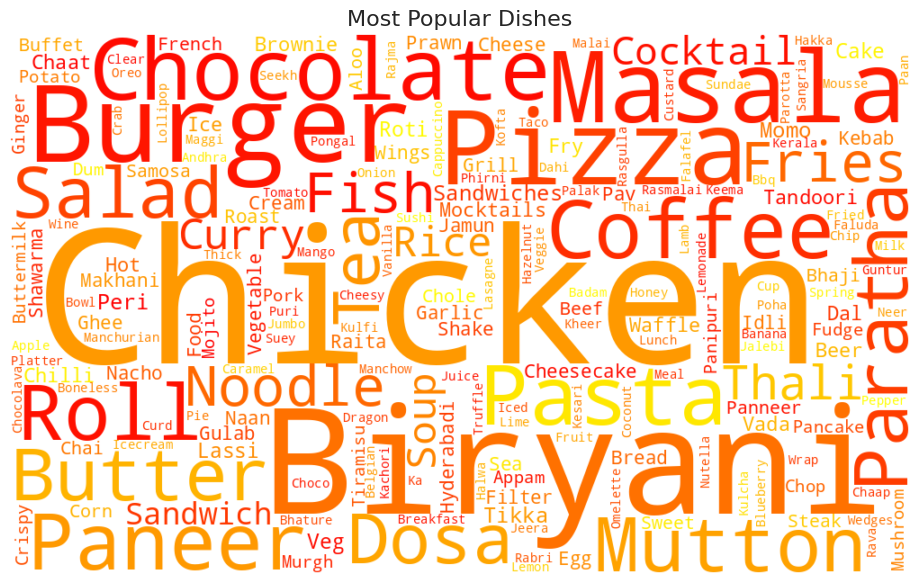

In [16]:
text_dishes = ' '.join(df['dish_liked'].dropna().str.replace(',', ' ').tolist())
wc_dishes = WordCloud(width=1000, height=600, background_color='white', colormap='autumn', collocations=False).generate(text_dishes)

plt.figure(figsize=(11,6))
plt.imshow(wc_dishes, interpolation='bilinear'); plt.axis('off')
plt.title('Most Popular Dishes', fontsize=16)
plt.tight_layout(); plt.show()

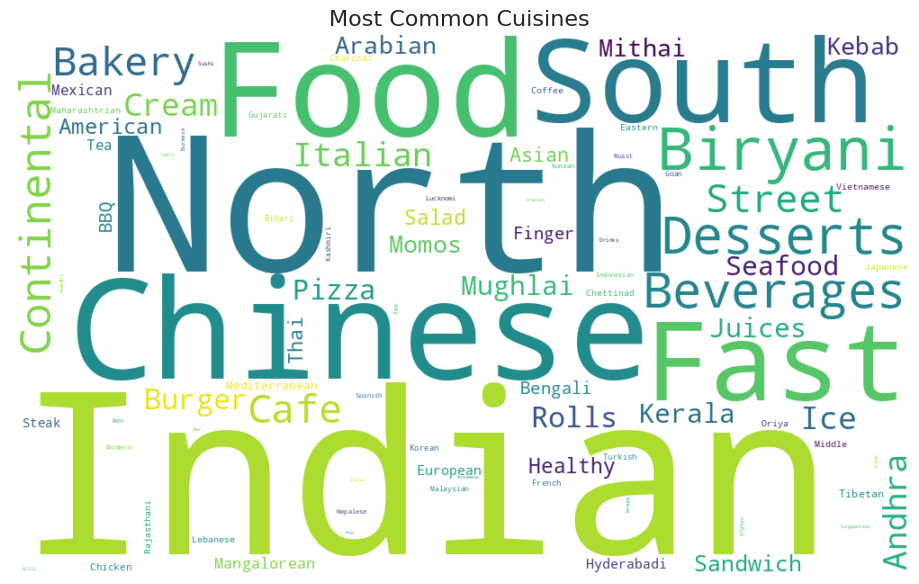

In [17]:
text_cuisines = ' '.join(df['cuisines'].dropna().str.replace(',', ' ').tolist())
wc_cuisines = WordCloud(width=1000, height=600, background_color='white', colormap='viridis', collocations=False).generate(text_cuisines)

plt.figure(figsize=(11,6))
plt.imshow(wc_cuisines, interpolation='bilinear'); plt.axis('off')
plt.title('Most Common Cuisines', fontsize=16)
plt.tight_layout(); plt.show()

## 5. Key Findings

1. **Data quality:** ~53% of the raw rows were structurally corrupted (fields shifted by upstream review text) and had to be dropped; the cleaned, deduplicated dataset has just over 10,000 unique restaurants.
2. **Ratings skew positive but rarely excellent:** average rating is ~3.6/5, with very few restaurants below 2.5 or above 4.5.
3. **Location concentration:** Electronic City, BTM, HSR, Whitefield and JP Nagar have the most listings — these are high-competition, high-supply micro-markets. Premium central areas (Lavelle Road, St. Marks Road, Church Street, Koramangala 5th Block) post the highest *average* ratings.
4. **Cuisine performance:** Continental, Desserts, Cafe, Italian and Asian cuisines rate consistently higher than the ubiquitous North Indian / Fast Food / Biryani categories, which are high-volume but middling on quality perception.
5. **Price correlates with rating:** cost for two and rating are positively correlated (r ≈ 0.30) — restaurants above ₹1,000 for two average well over 4.0, while budget spots (<₹600) average around 3.5.
6. **Service features matter:** table-booking restaurants average 4.07 vs 3.57 for non-booking ones — likely a proxy for fuller-service, sit-down establishments. Online-order availability shows a smaller but positive gap (3.64 vs 3.58).
7. **Restaurant format:** Fine Dining, Pubs and Lounges rate highest; Quick Bites, Takeaway and Food Courts rate lowest — format is a stronger differentiator than cuisine alone.


## 6. Recommendations for an Alfido-Tech-style Platform

1. **Prioritize partnerships in underserved-but-strong micro-markets** — areas like Koramangala 5th/4th Block, Indiranagar and Jayanagar combine solid restaurant density with above-average ratings, making them efficient targets for onboarding/partnership drives versus saturated zones like Electronic City where quality is more mixed.
2. **Build a "Hidden High-Raters" discovery feature** — surface Continental, Asian, Italian, and dessert/cafe concepts, which consistently outperform on rating but are far less numerous than North Indian/Biryani/Fast Food, giving users better choices and giving those restaurants more visibility than their size would otherwise earn.
3. **Launch tiered content/marketing around price-quality segments** — since higher price brackets reliably rate higher, create curated collections ("Best under ₹500", "Worth the splurge: ₹1500+") rather than one generic best-of list, helping different user budgets find genuinely well-rated options.
4. **Push table-booking and online-order adoption among partner restaurants** — both features are associated with materially higher ratings (booking especially, +0.5 points on average); a platform incentive or onboarding assistance program to get more restaurants offering these could lift the overall quality of the marketplace.
5. **Use location×cuisine heatmaps operationally** — the heatmap approach here (e.g. weak Chinese food in Bannerghatta Road, weak Fast Food ratings in Sarjapur Road and Electronic City) can guide where to encourage new-restaurant partnerships or menu improvements, and where to warn users about lower-quality clusters for a given cuisine.
